In [4]:
import numpy as np
import pandas as pd
import copy
from tqdm.auto import tqdm

from ensemble2 import DriftAdaptiveEnsemble

from utils.load_airline import FeatureDistrict, airline_stream
from utils.plot import plot_rmse_with_drift_by_district

from river.drift import ADWIN, PageHinkley
from river import metrics

from collections import defaultdict
from itertools import islice

import os

from river.forest import ARFRegressor
from river.tree import HoeffdingTreeRegressor

In [5]:
# pip install ipywidgets

In [6]:
DATASET_PATH = 'datasets/airline_processed.csv'
df = pd.read_csv(DATASET_PATH)
df = df.sort_values(by=['Year', 'Month', 'DayofMonth', 'CRSDepTime'])
rows = df.to_dict(orient="records")

In [7]:
DISTRICTS = ["South", "West", "Midwest", "Northeast", "Global"]

DISTRICTS_SETTINGS = {
    "South": {"delta_w": 0.7, "delta_c": 0.5, "window": 2000},    
    "West": {"delta_w": 0.7, "delta_c": 0.5, "window": 2000},         
    "Midwest": {"delta_w": 0.7, "delta_c":  0.5, "window": 300},    
    "Northeast": {"delta_w": 0.5, "delta_c": 0.2, "window": 200},    
    "Global": {"delta_w": 0.5, "delta_c": 0.1, "window": 1000}      
}

# def make_models(districts, district_settings, base_estimator, metric, **ensemble_kwargs):
#     return {
#         district: DriftAdaptiveEnsemble(
#             base_estimator=copy.deepcopy(base_estimator),
#             drift_detector=ADWIN(
#                 delta=district_settings[district]["delta_c"],
#             ),
#             warning_detector=ADWIN(
#                 delta=district_settings[district]["delta_w"],
#             ),
#             metric=copy.deepcopy(metric),
#             **ensemble_kwargs,
#         )
#         for district in districts
#     }

def make_models(districts, district_settings, base_estimator, metric, **ensemble_kwargs):
    return {
        district: DriftAdaptiveEnsemble(
            base_estimator=copy.deepcopy(base_estimator),
            drift_detector=PageHinkley(
                min_instances=5000, threshold=25
            ),
            warning_detector=PageHinkley(
                min_instances=1000, threshold=25
            ),
            metric=copy.deepcopy(metric),
            **ensemble_kwargs,
        )
        for district in districts
    }

In [8]:
MODELS = make_models(DISTRICTS, DISTRICTS_SETTINGS, HoeffdingTreeRegressor(), metrics.RMSE(), max_ensemble_size=5, retain_initial_model=True)
TRANSFORMER = FeatureDistrict()

In [9]:
def run(rows,
        transformer, 
        models,
        max_rows=None):

    if max_rows:
        rows = rows[:max_rows]

    records = []
    drift_records = []
    event_offsets = {k: 0 for k in models.keys()}

    print('Running')
    for i, (x_raw, y) in enumerate(tqdm(airline_stream(rows), total=max_rows or 1_000_000)):
        x = transformer.transform_one(x_raw)
        timestamp = x['timestamp']
        x.pop("timestamp")
        district = (
            x["pickup_district"]
            if x["within_district"] == 1
            else "Global"
        )
        x.pop("pickup_district", None)
        x.pop("dropoff_district", None)

        model = models[district]
        y_hat = model.predict_one(x)
        model.learn_one(x, y, timestamp)

        records.append({
            "i":         i,
            "timestamp": timestamp,
            "district":  district,
            "y":         y,
            "y_hat":     y_hat,
        })

        # collect any new drift events emitted by this model since last check
        log = model.drift_log
        offset = event_offsets[district]
        if len(log) > offset:
            for _, event in log.iloc[offset:].iterrows():
                drift_records.append({**event, "district": district})
            event_offsets[district] = len(log)

    df_res = pd.DataFrame(records)
    df_drift = pd.DataFrame(drift_records)

    df_res.to_csv("predictions.csv", index=False)
    df_drift.to_csv("drift_events.csv", index=False)

    return pd.DataFrame(records), pd.DataFrame(drift_records)

In [10]:
run(rows=rows, transformer=TRANSFORMER, models=MODELS, max_rows=1_000_000)

Running


 97%|█████████▋| 965174/1000000 [24:04<00:52, 668.10it/s]  


(             i           timestamp district     y          y_hat
 0            0 2008-01-01 00:00:00   Global  -3.0       0.000000
 1            1 2008-01-01 00:00:00   Global -19.0 -375027.997467
 2            2 2008-01-01 00:00:00   Global -24.0     -11.000000
 3            3 2008-01-01 00:00:00   Global  12.0     -15.333333
 4            4 2008-01-01 00:00:00     West  24.0       0.000000
 ...        ...                 ...      ...   ...            ...
 965169  965169 2008-02-21 09:00:00   Global  -8.0       8.790213
 965170  965170 2008-02-21 09:00:00   Global -18.0      -0.698351
 965171  965171 2008-02-21 09:00:00    South -18.0      -2.209565
 965172  965172 2008-02-21 09:00:00   Global  -5.0       7.809114
 965173  965173 2008-02-21 09:00:00   Global -19.0       5.305515
 
 [965174 rows x 5 columns],
               timestamp  n_seen event_type        ensemble_ids  shadow_id  \
 0   2008-01-01 10:00:00    2498    warning                 [0]        1.0   
 1   2008-01-01 15:00:

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_rmse_with_events(
    df_res,
    df_drift,
    start_date=None,
    end_date=None,
    window="1d",
    min_periods=1
):
    df = df_res.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    df_drift = df_drift.copy()
    df_drift["timestamp"] = pd.to_datetime(df_drift["timestamp"])

    # optional filtering
    if start_date:
        start_date = pd.to_datetime(start_date)
        df = df[df["timestamp"] >= start_date]
        df_drift = df_drift[df_drift["timestamp"] >= start_date]

    if end_date:
        end_date = pd.to_datetime(end_date)
        df = df[df["timestamp"] <= end_date]
        df_drift = df_drift[df_drift["timestamp"] <= end_date]

    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df["y_hat"] = pd.to_numeric(df["y_hat"], errors="coerce")
    df = df.dropna(subset=["y", "y_hat"])

    df["sq_error"] = (df["y"] - df["y_hat"]) ** 2

    districts = df["district"].unique()

    for d in districts:
        fig, ax = plt.subplots(figsize=(12, 5))

        ddf = df[df["district"] == d].sort_values("timestamp").set_index("timestamp")

        rmse = (
            ddf["sq_error"]
            .rolling(window, min_periods=min_periods)
            .mean()
            .apply(np.sqrt)
        )

        ax.plot(rmse.index, rmse.values, label="Rolling RMSE", color="blue")

        # events
        d_events = df_drift[df_drift["district"] == d]

        drift = d_events[d_events["event_type"] == "drift"]
        warning = d_events[d_events["event_type"] == "warning"]

        for t in drift["timestamp"]:
            ax.axvline(t, color="red", linestyle="--", alpha=0.7)

        for t in warning["timestamp"]:
            ax.axvline(t, color="orange", linestyle="--", alpha=0.7)

        ax.set_title(f"Rolling RMSE over time — District {d}")
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("RMSE")
        ax.grid(alpha=0.3)

        # clean legend (manual)
        ax.plot([], [], color="red", linestyle="--", label="Drift")
        ax.plot([], [], color="orange", linestyle="--", label="Warning")
        ax.plot([], [], color="blue", label="RMSE")

        ax.legend()

        plt.tight_layout()
        plt.show()

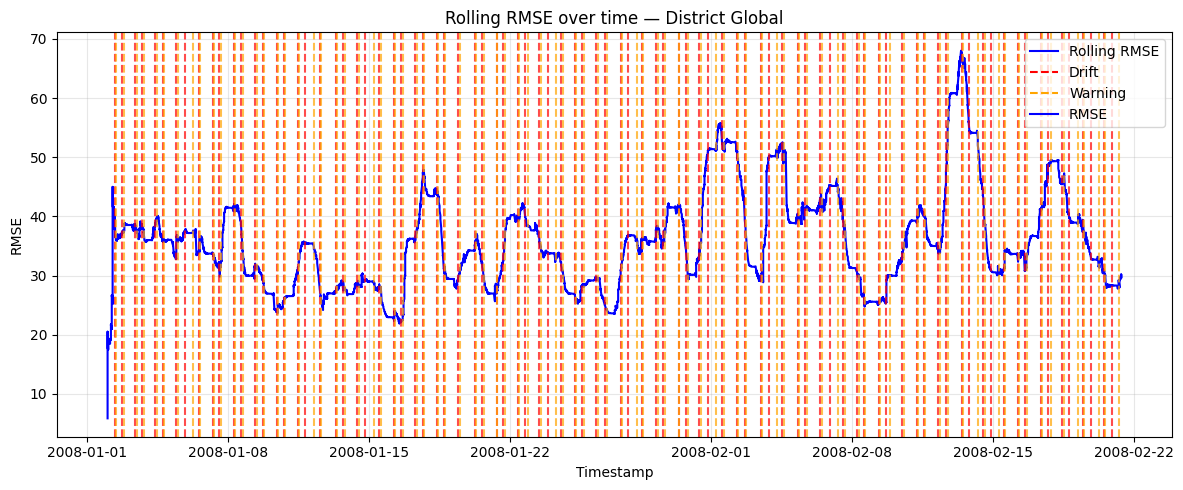

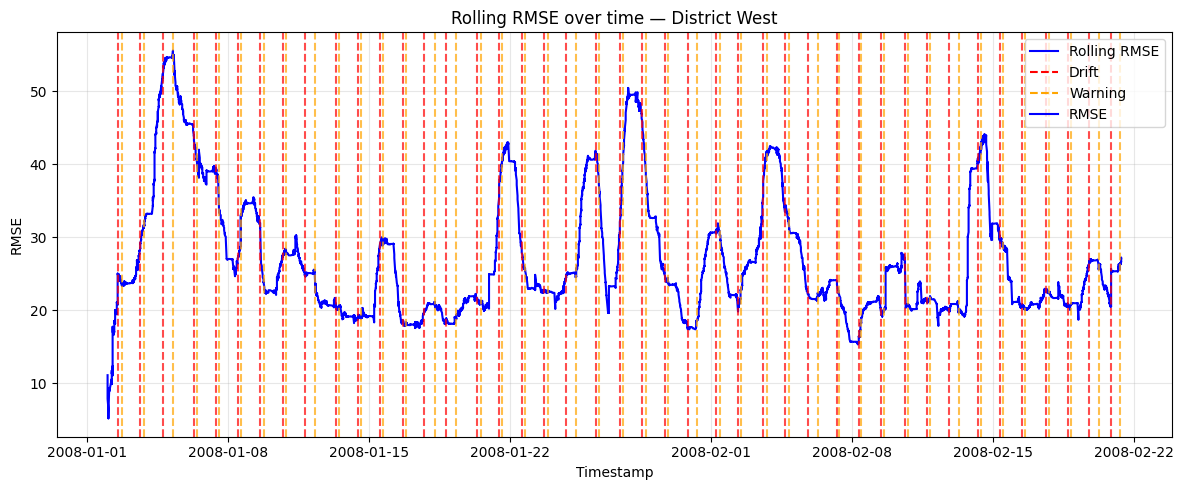

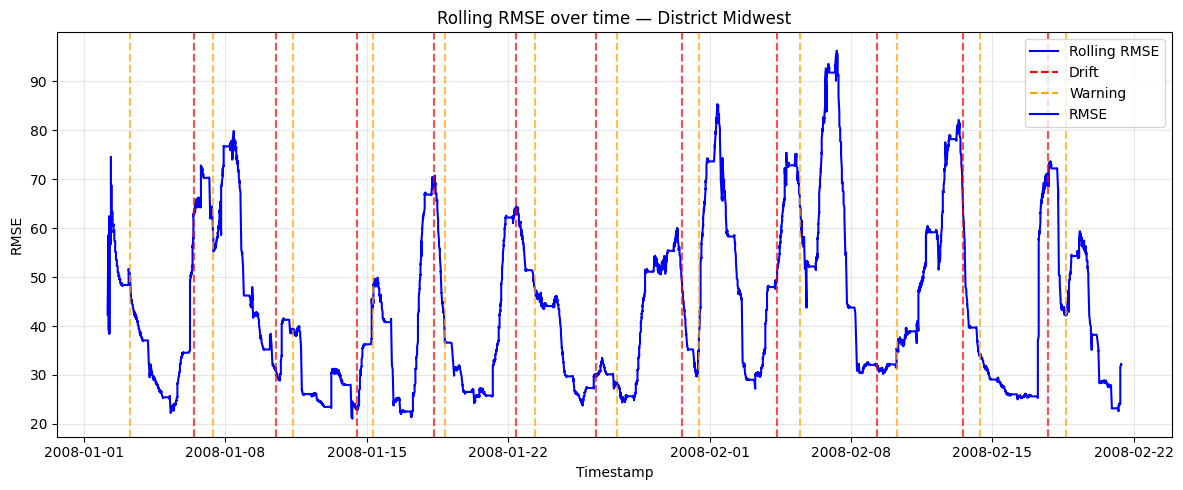

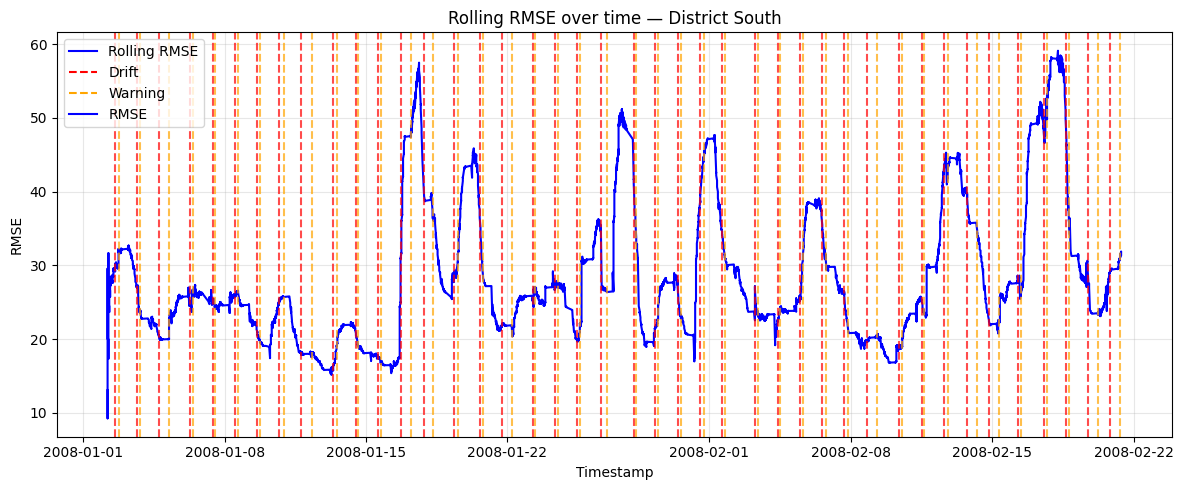

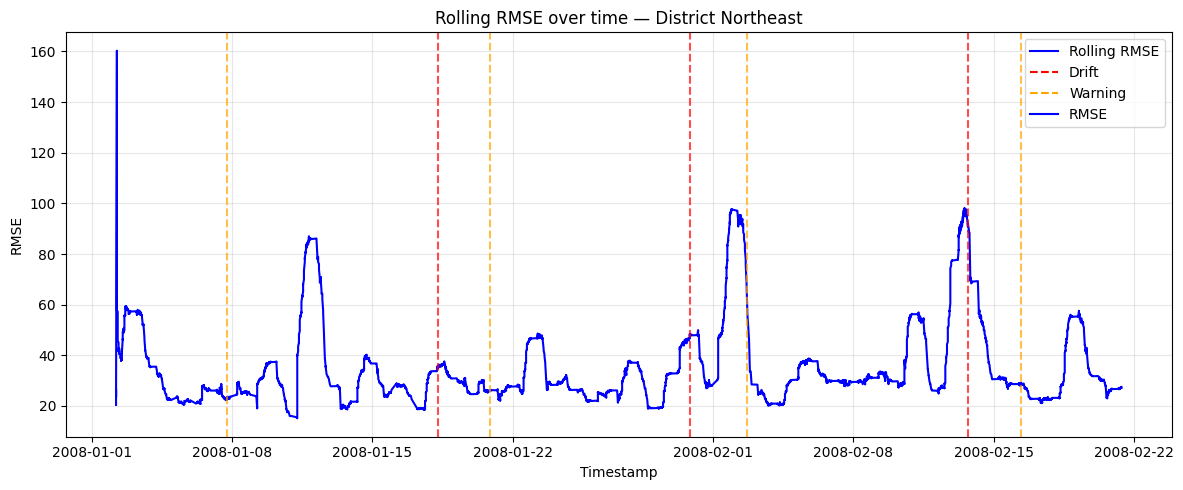

In [11]:
df_res = pd.read_csv('predictions.csv')
df_drift = pd.read_csv('drift_events.csv')

plot_rmse_with_events(
    df_res,
    df_drift,
    start_date='2008-01-02'
)